# Eigenmode and wave-field media

The `eigenmode` family solves a bounded standing-wave eigenproblem and
returns the chord-weighted superposition of the eigenmodes; the
`wave_field` family superposes coherent travelling waves on an unbounded
medium.

Same chord set, two very different physics.

In [1]:
import warnings
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt

from biotuner.harmonic_geometry import HarmonicInput, plotting

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

# A small reference set of chord inputs used across the notebook.
CHORDS = {
    "Major": HarmonicInput(ratios=[Fraction(1), Fraction(5, 4), Fraction(3, 2)]),
    "Sus4":  HarmonicInput(ratios=[Fraction(1), Fraction(4, 3), Fraction(3, 2)]),
    "Dom7":  HarmonicInput(ratios=[Fraction(1), Fraction(5, 4),
                                    Fraction(3, 2), Fraction(7, 4)]),
    "Dim7":  HarmonicInput(ratios=[Fraction(1), Fraction(6, 5),
                                    Fraction(7, 5), Fraction(12, 7)]),
}


## Eigenmode — `RigidPlate` across three domains

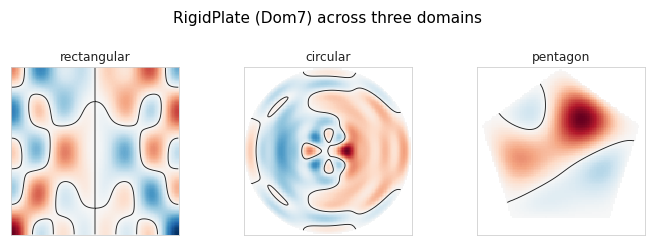

In [2]:
from biotuner.harmonic_geometry.media import (
    RigidPlate, ClosedSurface, Elastic, PlasmaLattice,
    Rectangular, Circular, PolygonDomain,
)

geoms = [
    RigidPlate(domain=Rectangular(),               resolution=128)(CHORDS["Dom7"]),
    RigidPlate(domain=Circular(R=1.0),             resolution=128)(CHORDS["Dom7"]),
    RigidPlate(domain=PolygonDomain(n_sides=5),    resolution=96)(CHORDS["Dom7"]),
]
plotting.gallery(geoms,
                 titles=["rectangular", "circular", "pentagon"],
                 n_cols=3,
                 suptitle="RigidPlate (Dom7) across three domains");


## Eigenmode — `ClosedSurface` on a sphere (chord-driven Y_lm modes)

The default ``mode_rule='zonal'`` uses only $(l, 0)$ modes, which have no
longitudinal variation — the sphere lights up symmetrically around the
poles. The other three rules expose richer chord-dependent geometry:

- ``sectoral``         — uses $|m| = l$ (banana-shaped equatorial lobes)
- ``chord_balanced``   — mixes $m \in \{0, ±1, …, ±l\}$ across components
- ``rounded``          — rounds $m$ proportional to the ratio magnitude


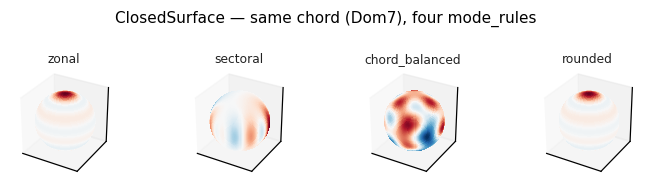

In [3]:
# Side-by-side comparison: same chord, four mode_rules
sphere_rules = ["zonal", "sectoral", "chord_balanced", "rounded"]
geoms = [ClosedSurface(mode_rule=r, max_l=12,
                        n_theta=96, n_phi=192)(CHORDS["Dom7"])
         for r in sphere_rules]
plotting.gallery(geoms, titles=sphere_rules, n_cols=4,
                 suptitle="ClosedSurface — same chord (Dom7), four mode_rules");


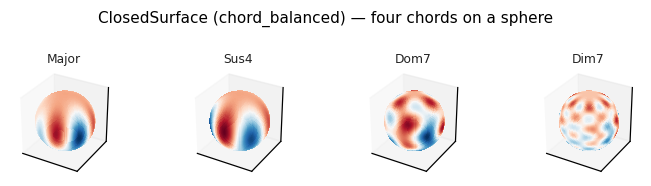

In [4]:
# Four chords, rendered with the visually richest mode_rule.
sphere = ClosedSurface(mode_rule="chord_balanced", max_l=12,
                       n_theta=96, n_phi=192)
geoms  = [sphere(CHORDS[n]) for n in CHORDS]
plotting.gallery(geoms, titles=list(CHORDS.keys()), n_cols=4,
                 suptitle="ClosedSurface (chord_balanced) — four chords on a sphere");


## Eigenmode — `Elastic` (anisotropy in the wave operator)

`Elastic` solves the elastic-wave eigenproblem on a rectangular domain
with an optional anisotropy axis. The fundamental mode is then
chord-modulated.

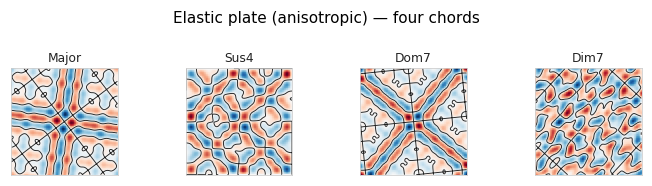

In [5]:
elastic = Elastic(resolution=160, n_modes=24)
geoms   = [elastic(CHORDS[n]) for n in CHORDS]
plotting.gallery(geoms, titles=list(CHORDS.keys()), n_cols=4,
                 suptitle="Elastic plate (anisotropic) — four chords");


## Eigenmode — `PlasmaLattice` (chord-tuned ion crystal)

A relaxed Coulomb crystal where the trapping potential is modulated by
the chord ratios; the medium returns the equilibrium ion positions as a
2-D point cloud.

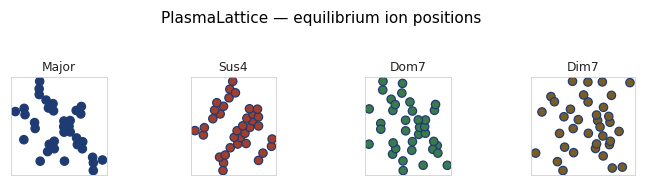

In [6]:
lattice = PlasmaLattice(n_ions=36, n_steps=200,
                         chord_resolution=128, rng_seed=0)
geoms   = [lattice(CHORDS[n]) for n in CHORDS]
plotting.gallery(geoms, titles=list(CHORDS.keys()), n_cols=4,
                 suptitle="PlasmaLattice — equilibrium ion positions");


## Wave-field — `Interference` (five paradigms)

`Interference` is a thin facade around the five travelling-wave
paradigms exposed in :mod:`harmonic_geometry.interference_patterns`.
The same chord becomes five visually distinct fields.

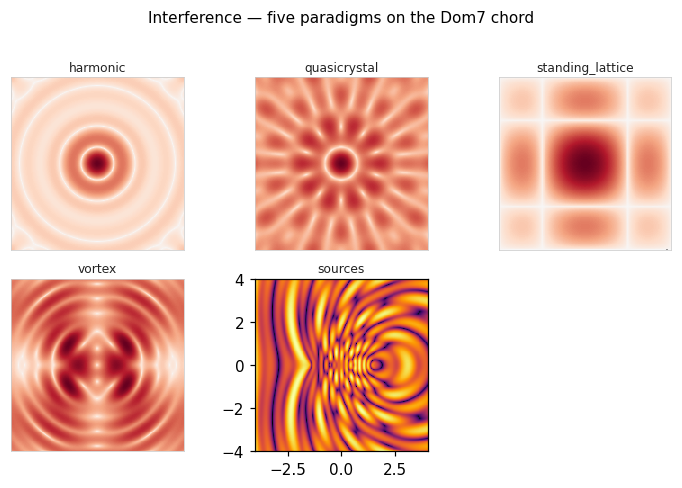

In [7]:
from biotuner.harmonic_geometry.media import Interference

paradigms = ["harmonic", "quasicrystal", "standing_lattice", "vortex", "sources"]
geoms = [Interference(paradigm=p, resolution=192)(CHORDS["Dom7"])
         for p in paradigms]
plotting.gallery(geoms, titles=paradigms, n_cols=3,
                 suptitle="Interference — five paradigms on the Dom7 chord");


## Wave-field — `Acoustic` (multi-source pressure field)

`Acoustic` places ``n_sources`` emitters on a configurable layout (a ring
by default), assigns one chord component per source, and superposes the
resulting outgoing pressure waves.

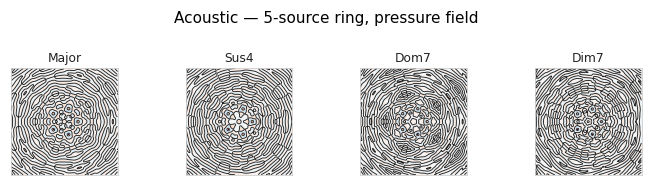

In [8]:
from biotuner.harmonic_geometry.media import Acoustic

acoustic = Acoustic(n_sources=5, source_layout="ring", resolution=224,
                    base_frequency=8.0)
geoms = [acoustic(CHORDS[n]) for n in CHORDS]
plotting.gallery(geoms, titles=list(CHORDS.keys()), n_cols=4,
                 suptitle="Acoustic — 5-source ring, pressure field");
